# Alzheimer's Detection Support System Using MONAI

---
Alzheimer’s disease is a devastating neuro disorder with no known cure. Early diagnosis is critical, as timely intervention can help medical professionals to prevent further progression. Traditional diagnostic methods such as clinical evaluations often detect the disease only after significant brain damage has already occurred.
This project demonstrates how to develop an automated, reproducible MRI‑based classificationdeep learning  model using
MONAI framework.

# Why MONAI?

MONAI - (Medical Open Network for AI) is an open‑source, PyTorch‑based framework designed specifically for medical imaging. It accelerates healthcare AI research by providing:

-Domain‑optimized neural network architecture
-Standardized medical imaging transforms
-Reproducible training pipelines
-Strong support for 2D and 3D imaging modalities
dalities

# Goal
The goal is to train a clasfication model for an input scan of an individual to predict any below class:


0:No Impairment
1:Very Mild Impairment
2:Mild Impairment
3:Moderate Impairment

#### Note - The full project run locally on Windows OS and using jupyter notebook

1. Install Anaconda - https://www.anaconda.com/docs/getting-started/anaconda/install
2. Open Anaconda Command prompt from the start menu
3. Create a fresh conda environment named as "monai-env" with Python 3.10
   ``conda create -n monai-env python=3.10 -y``

   ``conda activate monai-env``
4. Make sure Jupyter uses this environment
   ``pip install ipykernel``

   ``python -m ipykernel install --user --name monai-env --display-name "Python (monai-env)" ``
5. In opened Jupyter notebook (Untitled.ipynb --> rename it)
   Kernel → Change kernel → Python (monai-env) 

## 1. Install and Import Libraries

In [7]:
!pip install monai nibabel matplotlib scikit-learn

In [9]:
# 2. Install a CPU-only PyTorch (simplest, avoids CUDA)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install monai nibabel scikit-learn matplotlib


Looking in indexes: https://download.pytorch.org/whl/cpu


## 2. Test MONAI and Torch

In [10]:
import torch, monai
print("Torch:", torch.__version__)
print("MONAI:", monai.__version__)


Torch: 2.10.0+cpu
MONAI: 1.5.2


## 3. Data Transforms (Preprocessing Pipeline)

Transforms define how each MRI image is processed before entering the model.

### Transform Steps
- **LoadImageD** – Reads image from disk  
- **EnsureChannelFirstD** – Converts to shape `(C, H, W)`  
- **ResizeD** – Resizes all images to `(96, 96)`  
- **ScaleIntensityD** – Normalizes pixel values  
- **RandFlipD** – Random horizontal flip (data augmentation)  
- **ToTensorD** – Converts image + label to PyTorch tensors  

### Train vs Validation
- Training includes augmentation  
- Validation uses only deterministic transforms  

This ensures the model generalizes better while keeping validation consistent.
**Important Note** On the below cell Please notice the variable **data_dir**. This is my local and this is the path where you will point your downloaded dataset.

In [11]:
from monai.transforms import (
    LoadImageD,
    EnsureChannelFirstD,
    ResizeD,
    ScaleIntensityD,
    RandFlipD,
    ToTensorD,
    Compose
)




In [12]:
import os

data_dir = r"C:/Users/tomar/Documents/Work/UTAustin/AI-HealthCare/Assignment_Project/DataSet"

classes = {
    "No Impairment": 0,
    "Very Mild Impairment": 1,
    "Mild Impairment": 2,
    "Moderate Impairment": 3
}

train_dir = os.path.join(data_dir, "train")
test_dir  = os.path.join(data_dir, "test")

train_files = []
test_files = []

# TRAIN
for cls, label in classes.items():
    folder = os.path.join(train_dir, cls)
    for f in os.listdir(folder):
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            train_files.append({"image": os.path.join(folder, f), "label": label})

# TEST . Please note that TEST is used as a validation set during training and evaluation
for cls, label in classes.items():
    folder = os.path.join(test_dir, cls)
    for f in os.listdir(folder):
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            test_files.append({"image": os.path.join(folder, f), "label": label})

len(train_files), len(test_files)


(10240, 1279)

In [13]:
train_transforms = Compose([
    LoadImageD(keys=["image"]),
    EnsureChannelFirstD(keys=["image"]),
    ResizeD(keys=["image"], spatial_size=(96, 96)),
    ScaleIntensityD(keys=["image"]),
    RandFlipD(keys=["image"], prob=0.5, spatial_axis=1),
    ToTensorD(keys=["image", "label"]),
])

val_transforms = Compose([
    LoadImageD(keys=["image"]),
    EnsureChannelFirstD(keys=["image"]),
    ResizeD(keys=["image"], spatial_size=(96, 96)),
    ScaleIntensityD(keys=["image"]),
    ToTensorD(keys=["image", "label"]),
])


## 4. Create DataLoaders

MONAI's `CacheDataset` caches transformed data in memory for faster training.

### Components
- **CacheDataset** – Speeds up training by caching preprocessed images  
- **DataLoader** – Creates iterable batches for training and validation  

### Batch Size
Batch size = 4  
This is chosen to balance memory usage and training speed.

### Output
You verify shapes:
- Images: `(4, 1, 96, 96)`  
- Labels: `(4,)`  

This confirms the pipeline is working correctly.

In [14]:
from monai.data import CacheDataset, DataLoader

train_ds = CacheDataset(train_files, train_transforms)
val_ds   = CacheDataset(test_files,  val_transforms)   # using test as val for now

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=4)


C:\Users\tomar\anaconda3\envs\monai-env\lib\site-packages\monai\data\dataset.py:880: UserWarning: tqdm is not installed, will not show the caching progress bar.
  warnings.warn("tqdm is not installed, will not show the caching progress bar.")


In [15]:
batch = next(iter(train_loader))
images = batch["image"]
labels = batch["label"]

images.shape, labels.shape


(torch.Size([4, 1, 96, 96]), torch.Size([4]))

## 5. Build the CNN Model

This section defines the deep learning model used for MRI classification.

### Model Architecture
Using MONAI’s `resnet18`:
- 2D convolutional model  
- Input channels = 1 (grayscale MRI slices)  
- Output classes = 4  

### Training Components
- **Loss Function:** CrossEntropyLoss  
- **Optimizer:** Adam (learning rate = 1e‑4)  
- **Device:** CPU or GPU (auto-detected)  

This model is lightweight, fast, and effective for 2D MRI classification.

In [17]:
from monai.networks.nets import DenseNet121
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = DenseNet121(
#     spatial_dims=2,
#     in_channels=1,
#     out_channels=4
# ).to(device)

from monai.networks.nets import resnet18

model = resnet18(
    spatial_dims=2,
    n_input_channels=1,
    num_classes=4
).to(device)


loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [18]:
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    preds = model(images)

preds.shape


torch.Size([4, 4])

## 6. Training Loop

This loop trains the model for a specified number of epochs.

### Steps per Epoch
1. Set model to training mode  
2. Forward pass  
3. Compute loss  
4. Backpropagate  
5. Update weights  
6. Track average loss  

### Output
Loss decreases each epoch, indicating learning progress.

In [20]:
num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for batch in train_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        preds = model(images)
        loss = loss_fn(preds, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_loss = train_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")


Epoch 1/3 - Loss: 0.6791
Epoch 2/3 - Loss: 0.4352
Epoch 3/3 - Loss: 0.3060


## 7. Validation Accuracy

After training, the model is evaluated on the validation set.

### Metrics
- Predictions are compared with ground truth  
- Accuracy = correct predictions / total samples  

This gives a quick snapshot of model performance.

In [21]:
# Validation 
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch in val_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        preds = model(images)
        predicted = torch.argmax(preds, dim=1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

val_acc = correct / total
print("Validation Accuracy:", val_acc)


Validation Accuracy: 0.766223612197029


In [29]:
test_ds  = CacheDataset(test_files,  val_transforms)
test_loader  = DataLoader(test_ds, batch_size=4)


In [33]:
batch = next(iter(test_loader))
batch["image"].shape, batch["label"].shape


(torch.Size([4, 1, 96, 96]), torch.Size([4]))

# Test Set Evaluation
## 8. Test Set Evaluation

This section evaluates the model on unseen test data.

### Metrics Used
- **Confusion Matrix**  
- **Classification Report**  
  - Precision  
  - Recall  
  - F1-score  

### Purpose
This helps identify:
- Which classes the model predicts well  
- Where misclassifications occur  
- Class imbalance effects  

In [31]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        preds = model(images)
        predicted = torch.argmax(preds, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=list(classes.keys())))


[[549  30  61   0]
 [129 254  65   0]
 [  5   9 165   0]
 [  0   0   0  12]]
                      precision    recall  f1-score   support

       No Impairment       0.80      0.86      0.83       640
Very Mild Impairment       0.87      0.57      0.69       448
     Mild Impairment       0.57      0.92      0.70       179
 Moderate Impairment       1.00      1.00      1.00        12

            accuracy                           0.77      1279
           macro avg       0.81      0.84      0.80      1279
        weighted avg       0.79      0.77      0.76      1279



# 9. Loss & Accuracy Plots
These plots help diagnose:
- Underfitting  
- Overfitting  
- Training stability 

In [35]:
import matplotlib.pyplot as plt

train_losses = []
val_accuracies = []

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for batch in train_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        preds = model(images)
        loss = loss_fn(preds, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_loss = train_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validation accuracy
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

            preds = model(images)
            predicted = torch.argmax(preds, dim=1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f} - Val Acc: {val_acc:.4f}")


Epoch 1/10 - Loss: 0.2060 - Val Acc: 0.8726
Epoch 2/10 - Loss: 0.1528 - Val Acc: 0.9156
Epoch 3/10 - Loss: 0.1076 - Val Acc: 0.9054
Epoch 4/10 - Loss: 0.0916 - Val Acc: 0.8890
Epoch 5/10 - Loss: 0.0784 - Val Acc: 0.8733
Epoch 6/10 - Loss: 0.0659 - Val Acc: 0.9382
Epoch 7/10 - Loss: 0.0559 - Val Acc: 0.9625
Epoch 8/10 - Loss: 0.0522 - Val Acc: 0.9578
Epoch 9/10 - Loss: 0.0465 - Val Acc: 0.9367
Epoch 10/10 - Loss: 0.0427 - Val Acc: 0.9625


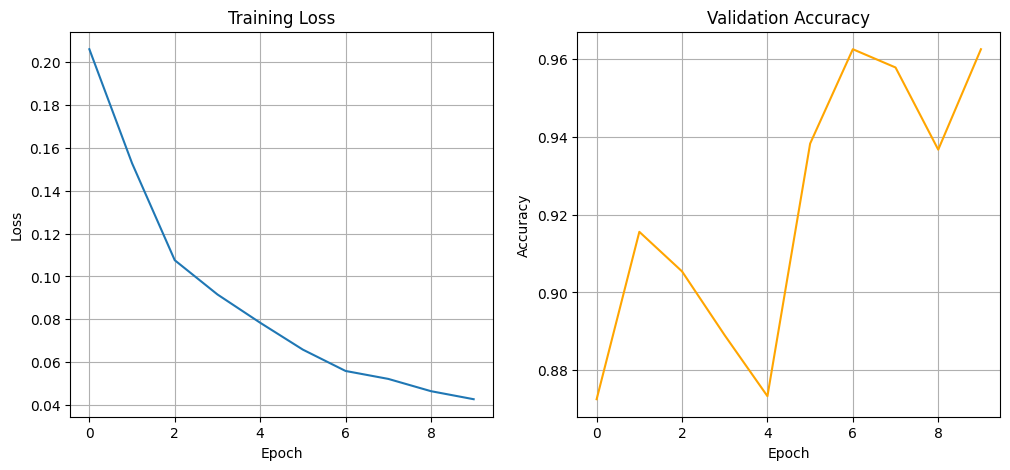

In [36]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(val_accuracies, label="Validation Accuracy", color="orange")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()


In [228]:
plt.savefig("loss_accuracy.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [62]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 1.7 MB/s eta 0:00:07
   --- ------------------------------------ 1.0/11.3 MB 2.2 MB/s eta 0:00:05
   ------ --------------------------------- 1.8/11.3 MB 2.7 MB/s eta 0:00:04
   --------- ------------------------------ 2.6/11.3 MB 3.4 MB/s eta 0:00:03
   ------------ --------------------------- 3.7/11.3 MB 3.3 MB/s eta 0:00:03
   --------------- ------------------------ 4.5/11.3 MB 3.5 MB/s eta 0:00:02
   --------------- ------------------------ 4.5/11.3 MB 3.5 MB/s eta 0:00:02
   -------------------- ------------------- 5.8/11.3 MB 3.4 MB/s

## 10. Confusion Matrix
This highlights:
- Which impairment levels are confused  
- Strengths and weaknesses of the model 

In [63]:
import torch
import numpy as np

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)
        labels = batch["label"].cpu().numpy()

        preds = model(images)
        predicted = torch.argmax(preds, dim=1).cpu().numpy()

        y_true.extend(labels)
        y_pred.extend(predicted)


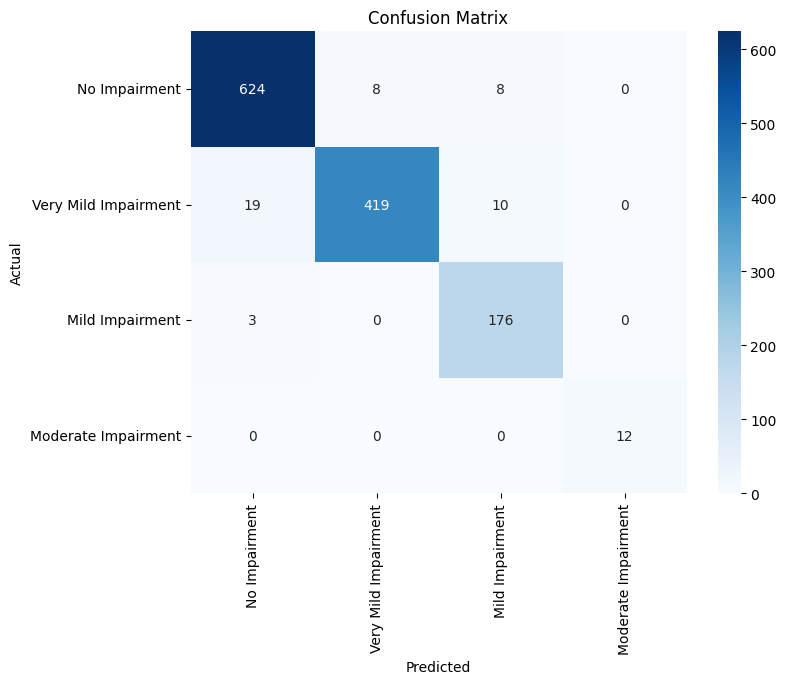

In [64]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Convert class dictionary to ordered list
class_names = list(classes.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [230]:
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

In [65]:
import seaborn as sns
print(sns.__version__)

0.13.2


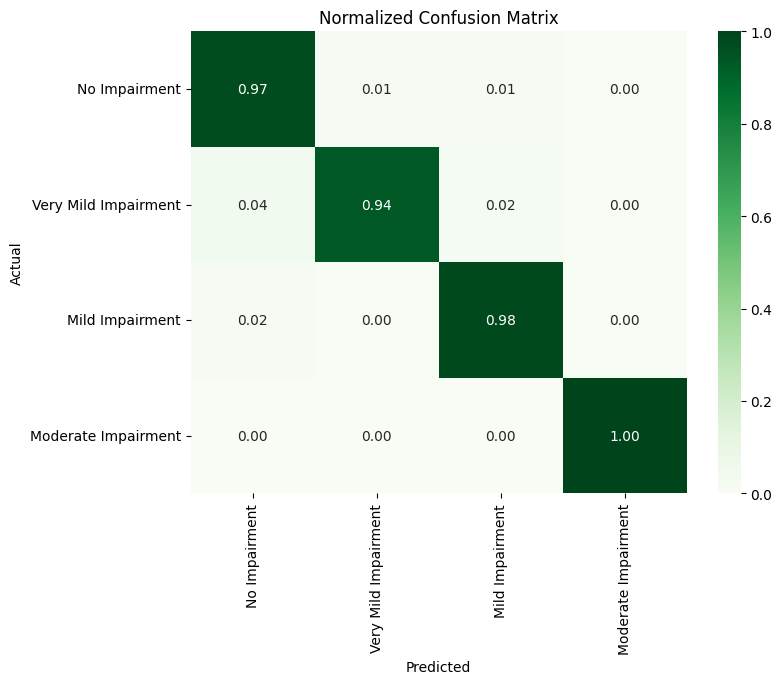

In [66]:
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix")
plt.show()


In [232]:
plt.savefig("confusion_matrix_normalized.png", dpi=300, bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

## 11. Single‑Image Prediction Test

This section demonstrates how to run the trained model on a single MRI image.  
It helps Medical professional to  verify an individual sample and replicate the workflow for their own images.to predict the disease 

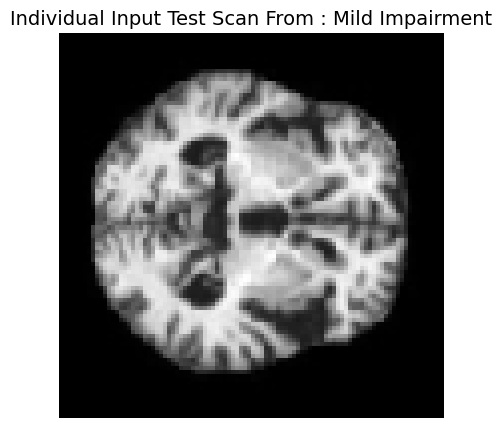

Predicted Class by trained MODEL =====> : Mild Impairment


In [191]:
import matplotlib.pyplot as plt
from monai.transforms import Compose, LoadImage, EnsureChannelFirst, Resize, ScaleIntensity, ToTensor

# --- Image-only transform for prediction ---
predict_transform = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((96, 96)),
    ScaleIntensity(),
    ToTensor()
])

# --- Path to the test image ---
test_sample = "Mild Impairment"
test_image = "./DataSet/test/Mild Impairment/1 (2).jpg"

# --- Load + preprocess ---
img_tensor = predict_transform(test_image).unsqueeze(0).to(device)

# --- Predict ---
model.eval()
with torch.no_grad():
    pred = model(img_tensor)
    pred_class = pred.argmax(dim=1).item()

class_names = [
    "No Impairment",
    "Very Mild Impairment",
    "Mild Impairment",
    "Moderate Impairment"
]

pred_label = class_names[pred_class]

# --- Show image + prediction ---
plt.figure(figsize=(5,5))
plt.imshow(img_tensor.cpu().squeeze().numpy(), cmap="gray")
plt.title(f"Individual Input Test Scan From : {test_sample}", fontsize=14)
#plt.title(f"Predicted: {pred_label}", fontsize=14)
plt.axis("off")
plt.show()

print("Predicted Class by trained MODEL =====> :", pred_label)


## 12. Conclusion

This project is a complete deep‑learning pipeline for classifying cognitive impairment (Alzimers) levels from MRI images using MONAI and PyTorch. This notebook provides a reproducible, end‑to‑end workflow that can be extended to larger datasets or more advanced architectures.  